In [102]:
import numpy as np
import pandas as pd
dt = pd.DataFrame({"cgpa":[8,7,6,5],
                   "PS":[8,9,10,5],
                   'placed':[1,1,0,0]})

In [103]:
X=dt[['cgpa','PS']]
X

,cgpa,PS
0,8,8
1,7,9
2,6,10
3,5,5


In [104]:
y= dt['placed']
y

0    1
1    1
2    0
3    0
Name: placed, dtype: int64

In [105]:
X=np.array(X)

In [106]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [107]:
alpha = 0.01
epochs =100
m=4
tol=0.0001

W1=np.random.random(size=(2,2))
B1=np.random.random(size=(2,1))
W2=np.random.random(size=(2,1))
B2=np.random.random(size=(1,1))

avg_loss = [0]
epochs_count = []
for i in range(epochs):
  arr=np.arange(X.shape[0])
  np.random.shuffle(arr)
  X=X[arr]
  y = y[arr]
  print(f"Epoch : {i+1}")
  loss=[]
  for j in range(m):
    #Forward Propagation
    #Layer 1
    zp= W1.T@X[j].reshape(-1, 1)+B1
    o1 = sigmoid(zp)
    #Layer 2
    zf = W2.T@o1+B2
    ypred = sigmoid(zf)
    ytrue = y[j]
    #loss
    l = -ytrue*np.log(ypred) - (1-ytrue)*np.log(1-ypred)
    loss.append(l)
    # Backward Propogation
    # partial derivatives
    # set 1
    delL_by_delo_21= -ytrue/ypred +(1-ytrue)/(1-ypred)
    delo_21_by_delzf= sigmoid(zf)*(1-sigmoid(zf))
    delzf_by_delw2_11 = o1[0]
    delzf_by_delw2_21= o1[1]
    delzf_by_delb21 = 1
    delL_by_delw2_11 = delL_by_delo_21 * delo_21_by_delzf * delzf_by_delw2_11
    delL_by_delw2_21 = delL_by_delo_21 * delo_21_by_delzf * delzf_by_delw2_21
    delL_by_delb21 = delL_by_delo_21 * delo_21_by_delzf * delzf_by_delb21
     # set 2
    delL_by_delw1_11 = -(ytrue-ypred)*W2[0]*o1[0]*(1-o1[0])*X[j,0]
    delL_by_delw1_21 = -(ytrue-ypred)*W2[0]*o1[0]*(1-o1[0])*X[j,1]
    delL_by_delb11 = -(ytrue-ypred)*W2[0]*o1[0]*(1-o1[0])
     # set 3
    delL_by_delw1_12 = -(ytrue-ypred)*W2[1]*o1[1]*(1-o1[1])*X[j,0]
    delL_by_delw1_22 = -(ytrue-ypred)*W2[1]*o1[1]*(1-o1[1])*X[j,1]
    delL_by_delb12 = -(ytrue-ypred)*W2[1]*o1[1]*(1-o1[1])
    # gradient descent updates
    # set 1
    W2[0][0] = W2[0][0] - alpha*delL_by_delw2_11[0][0]
    W2[1][0] = W2[1][0] - alpha*delL_by_delw2_21[0][0]
    B2[0][0] = B2[0][0] - alpha*delL_by_delb21[0][0]
    # set 2
    W1[0][0] = W1[0][0] - alpha*delL_by_delw1_11[0][0]
    W1[1][0] = W1[1][0] - alpha*delL_by_delw1_21[0][0]
    B1[0][0] = B1[0][0] - alpha*delL_by_delb11[0][0]
    # set 3
    W1[0][1] = W1[0][1] - alpha*delL_by_delw1_12[0][0]
    W1[1][1] = W1[1][1] - alpha*delL_by_delw1_22[0][0]
    B1[1][0] = B1[1][0] - alpha*delL_by_delb12[0][0]

  avg_loss.append(np.mean(loss))
  epochs_count.append(i)
  if abs(avg_loss[-1]-avg_loss[-2]) <=tol:
    print("Loss Stagnates")
    break
  print(f"Avg Loss : {np.mean(loss)}")
  

Epoch : 1
Avg Loss : 0.9819306617708365
Epoch : 2
Avg Loss : 0.9686127614396411
Epoch : 3
Avg Loss : 0.9565473260169635
Epoch : 4
Avg Loss : 0.9441496938767732
Epoch : 5
Avg Loss : 0.9329151899483831
Epoch : 6
Avg Loss : 0.9214303197490736
Epoch : 7
Avg Loss : 0.9109903379085793
Epoch : 8
Avg Loss : 0.9006331033189887
Epoch : 9
Avg Loss : 0.890670341639607
Epoch : 10
Avg Loss : 0.8809149437673558
Epoch : 11
Avg Loss : 0.8719811186712995
Epoch : 12
Avg Loss : 0.8630391081245081
Epoch : 13
Avg Loss : 0.854665450632158
Epoch : 14
Avg Loss : 0.846761454190532
Epoch : 15
Avg Loss : 0.8390276652166002
Epoch : 16
Avg Loss : 0.8316186364906528
Epoch : 17
Avg Loss : 0.8245944032843338
Epoch : 18
Avg Loss : 0.8179601473467482
Epoch : 19
Avg Loss : 0.8115526177142074
Epoch : 20
Avg Loss : 0.8054683764258141
Epoch : 21
Avg Loss : 0.7996256683210262
Epoch : 22
Avg Loss : 0.794083315143082
Epoch : 23
Avg Loss : 0.7888880935315659
Epoch : 24
Avg Loss : 0.7838301003061124
Epoch : 25
Avg Loss : 0.77914

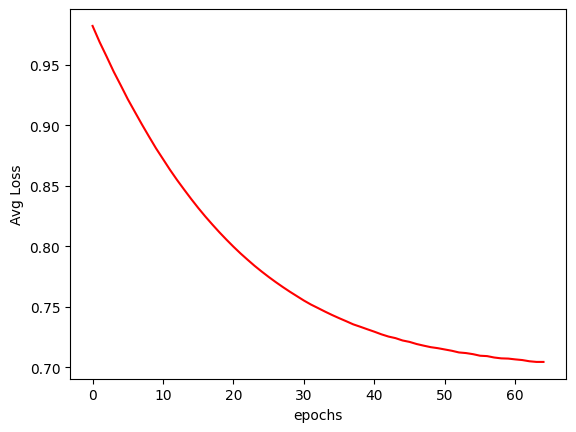

In [108]:
import matplotlib.pyplot as plt

plt.plot(epochs_count, avg_loss[1:], c = "red")
plt.xlabel("epochs"); plt.ylabel("Avg Loss")
plt.show()